<a href="https://colab.research.google.com/github/ProstoRav/Netology/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%C2%AB%D0%A1%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8_%D0%B4%D0%B5%D1%82%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

## Загрузка данных

In [2]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle competitions download -c digit-recognizer

100% 15.3M/15.3M [00:00<00:00, 81.9MB/s]



In [3]:
!mkdir -p ./data/digit
!unzip -o /content/digit-recognizer.zip -d ./data/digit

Archive:  /content/digit-recognizer.zip
  inflating: ./data/digit/sample_submission.csv  
  inflating: ./data/digit/test.csv   
  inflating: ./data/digit/train.csv  


In [4]:
!ls -la ./data/digit

total 125144
drwxr-xr-x 2 root root     4096 Mar 18 20:59 .
drwxr-xr-x 3 root root     4096 Mar 18 20:59 ..
-rw-r--r-- 1 root root   240909 Dec 11  2019 sample_submission.csv
-rw-r--r-- 1 root root 51118296 Dec 11  2019 test.csv
-rw-r--r-- 1 root root 76775041 Dec 11  2019 train.csv


In [5]:
def resolve_data_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path("./data/digit") / filename,
        Path("/mnt/data") / filename,
        Path("/content") / filename,
        Path("/content/data/digit") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Не найден файл {filename}. Проверены пути: {candidates}")

train_path = resolve_data_path("train.csv")
test_path = resolve_data_path("test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("train:", train_df.shape)
print("test :", test_df.shape)

train: (42000, 785)
test : (28000, 784)


In [6]:
X = train_df.drop(columns=["label"]).to_numpy(dtype=np.float32)
y = train_df["label"].to_numpy(dtype=np.int32)
X_test = test_df.to_numpy(dtype=np.float32)

# Преобразование формы: (N, 784) -> (N, 28, 28)
X_img = X.reshape(-1, 28, 28) / 255.0
X_test_img = X_test.reshape(-1, 28, 28) / 255.0

print("X_img     :", X_img.shape)
print("X_test_img:", X_test_img.shape)

X_img     : (42000, 28, 28)
X_test_img: (28000, 28, 28)


## Визуализация нескольких примеров

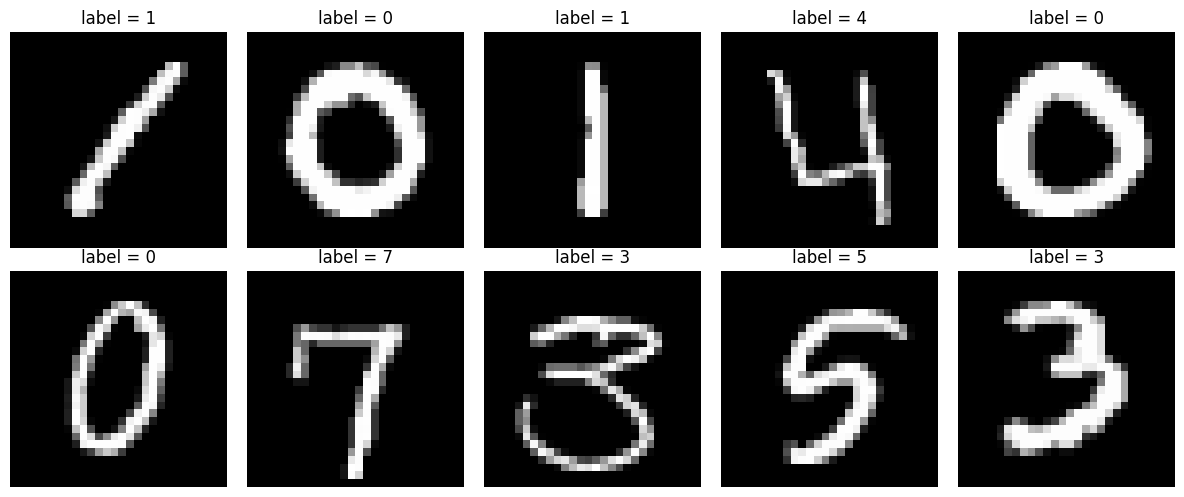

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(X_img[idx], cmap="gray")
    ax.set_title(f"label = {y[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Извлечение HOG-признаков

In [8]:
def extract_hog_features(images: np.ndarray, batch_size: int = 6000) -> np.ndarray:
    features = []
    for start in range(0, len(images), batch_size):
        batch = images[start:start + batch_size]
        batch_features = np.array(
            [
                hog(
                    image,
                    orientations=9,
                    pixels_per_cell=(4, 4),
                    cells_per_block=(2, 2),
                    block_norm="L2-Hys",
                    feature_vector=True,
                )
                for image in batch
            ],
            dtype=np.float32,
        )
        features.append(batch_features)
        print(f"processed: {start:>5} .. {min(start + batch_size, len(images)):>5}")
    return np.vstack(features)

X_hog = extract_hog_features(X_img)
X_test_hog = extract_hog_features(X_test_img)

print("X_hog     :", X_hog.shape)
print("X_test_hog:", X_test_hog.shape)

processed:     0 ..  6000
processed:  6000 .. 12000
processed: 12000 .. 18000
processed: 18000 .. 24000
processed: 24000 .. 30000
processed: 30000 .. 36000
processed: 36000 .. 42000
processed:     0 ..  6000
processed:  6000 .. 12000
processed: 12000 .. 18000
processed: 18000 .. 24000
processed: 24000 .. 28000
X_hog     : (42000, 1296)
X_test_hog: (28000, 1296)


## Разбиение на обучение и валидацию

In [9]:
X_train, X_val, X_img_train, X_img_val, y_train, y_val = train_test_split(
    X_hog,
    X_img,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("train features:", X_train.shape)
print("val features  :", X_val.shape)
print("train images  :", X_img_train.shape)
print("val images    :", X_img_val.shape)
print("y train / val :", y_train.shape, y_val.shape)

train features: (33600, 1296)
val features  : (8400, 1296)
train images  : (33600, 28, 28)
val images    : (8400, 28, 28)
y train / val : (33600,) (8400,)


## Обучение модели

In [10]:
clf = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000,
)

clf.fit(X_train, y_train)
pred_val = clf.predict(X_val)

## Оценка качества на валидации

In [11]:
acc = accuracy_score(y_val, pred_val)
print(f"Validation accuracy: {acc:.6f}")

Validation accuracy: 0.977024


In [12]:
print(classification_report(y_val, pred_val, digits=4))

              precision    recall  f1-score   support

           0     0.9809    0.9915    0.9862       827
           1     0.9862    0.9936    0.9899       937
           2     0.9772    0.9760    0.9766       835
           3     0.9736    0.9747    0.9742       870
           4     0.9802    0.9730    0.9766       814
           5     0.9788    0.9710    0.9749       759
           6     0.9831    0.9831    0.9831       827
           7     0.9717    0.9750    0.9733       880
           8     0.9788    0.9643    0.9715       813
           9     0.9597    0.9654    0.9625       838

    accuracy                         0.9770      8400
   macro avg     0.9770    0.9768    0.9769      8400
weighted avg     0.9770    0.9770    0.9770      8400



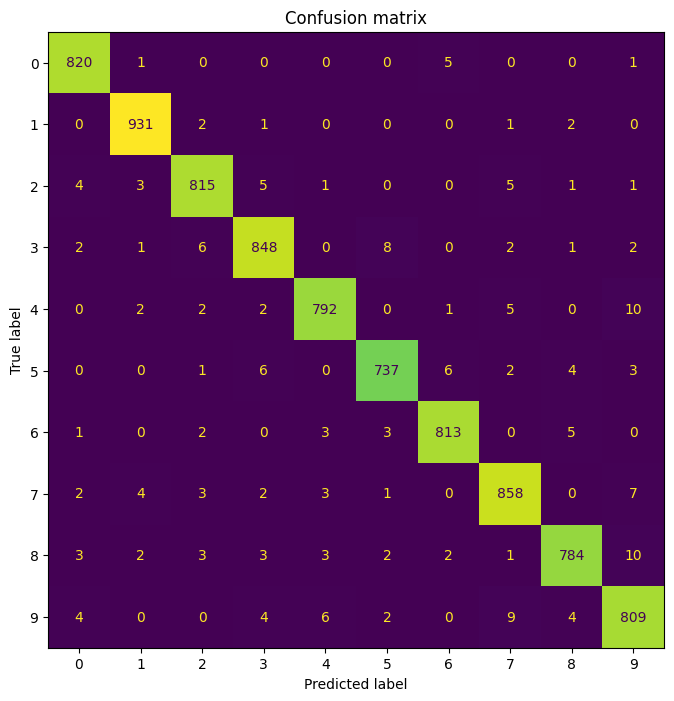

In [13]:
cm = confusion_matrix(y_val, pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion matrix")
plt.show()

## Несколько ошибок модели

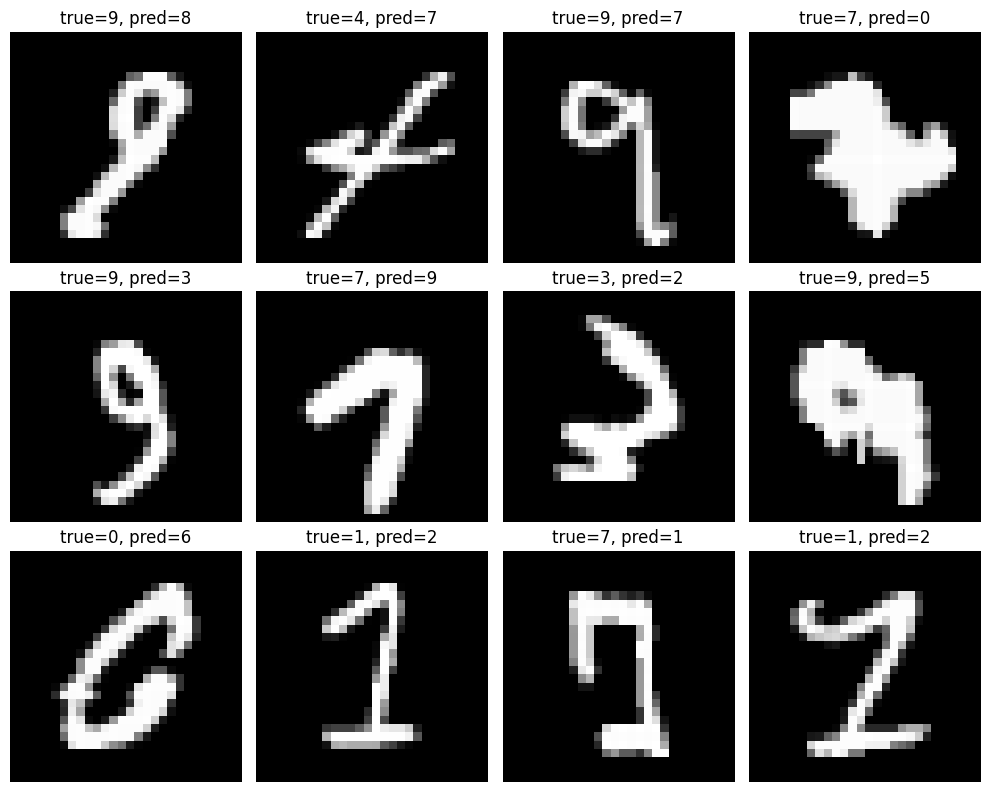

In [14]:
wrong_idx = np.where(pred_val != y_val)[0][:12]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, idx in zip(axes.ravel(), wrong_idx):
    ax.imshow(X_img_val[idx], cmap="gray")
    ax.set_title(f"true={y_val[idx]}, pred={pred_val[idx]}")
    ax.axis("off")

for ax in axes.ravel()[len(wrong_idx):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Обучаем модель на полном `train.csv` и формируем файл отправки для Kaggle

In [15]:
final_clf = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000,
)

final_clf.fit(X_hog, y)
pred_test = final_clf.predict(X_test_hog)
pred_test[:10]

array([2, 0, 9, 0, 3, 7, 0, 3, 0, 3], dtype=int32)

In [17]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(pred_test) + 1),
    "Label": pred_test.astype(int),
})

submission_path = Path("submission.csv")
submission.to_csv(submission_path, index=False)

print(f"Файл сохранён: {submission_path.resolve()}")
submission.head()

Файл сохранён: /content/submission.csv


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [18]:
!kaggle competitions submit -c digit-recognizer -f submission.csv  -m "Message"

100% 208k/208k [00:00<00:00, 345kB/s]
Successfully submitted to Digit Recognizer

In [20]:
!kaggle competitions submissions -c digit-recognizer

fileName        date                        description  status                     publicScore  privateScore  
--------------  --------------------------  -----------  -------------------------  -----------  ------------  
submission.csv  2026-03-18 21:09:12.250000  Message      SubmissionStatus.COMPLETE  0.97800                    
